In [1]:
from scipy.spatial.transform import Rotation, RigidTransform
import numpy as np

In [2]:
!pip install scipy

The RF link budget is based on the Friis transmission equation with FSPL. 


$$P_{in} = P_{tx} + G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}})+G_{t} - L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) - L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{t}})$$
$$P_{rx} = P_{tx} + 2G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}})+2G_{t} - 2(L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) + L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{t}})) - L_{\text{scatter}}$$
$$\text{RSSI}=P_{rx}+\eta_{meas}$$
$$\eta_{meas} \sim N(0, \sigma_{rssi}^{2})$$

- $x_{r}$ is vector from origin to antenna (receiver).
- $x_{t}$ is vector from origin to tag.
- $\theta_{r}$ is antenna (receiver) boresight vector. Assumed to be a unit vector in x-axis at no rotation.
- $\theta_{t}$ is tag orientation vector. Assumed to be a unit vector in x-axis at no rotation.

We assume here that both the antenna and the tags are linearly-polarised.

### Antenna Power, $P_{tx}$
- `antenna_power`: $P_{tx}$ is transmit power (dBm). Default of 30 dBm.

### Antenna Gain, $G_{r}$ (dBi)
Losses arising from angle between antenna boresight, and vector from antenna to tag. This angle is $\theta_{b}$.
$$G_{r}(\mathbf{\theta_{r}}, \mathbf{x_{r}}, \mathbf{x_{t}}) = G_{r, peak} - \min(l_{max}, 12\cdot(\frac{\theta_{b}}{\theta_{3dB}})^{2})$$
$$\cos{\theta_{b}} = \frac{(\mathbf{x_t}-\mathbf{x_r})\cdot\theta_{r}}{|(\mathbf{x_t}-\mathbf{x_r})||\theta_{r}|}$$
- `antenna_gain_peak`: $G_{r, peak}$ is assumed gain when we have a $0$ angle (i.e. antenna pointed directly at tag. Default of $6$ (dBi)
- `antenna_gain_max_loss`: $l_{max}$ is used to cap our maximum loss. Default of $25$ (dBi)
- `antenna_gain_half_beamwidth`: $\theta_{3dB}$ is angle at which antenna gain is 50% of peak. Default of $0$ (dBi). Default of 40 deg (0.7rad)
  

### Tag Gain, $G_{t}$ (dBi)
- `tag_directional_gain`: $G_{t}$ is assumed to be negligible in this model. 

### Path Loss, $L_{path}$ (dB)
Losses arising from distance between antenna and tag. Loss increases logarithmically with distance.

$$L_{path}(\mathbf{x_{r}}, \mathbf{x_{t}}) = L_{base} + 10\cdot c_{los}\cdot \log_{10}(\max(d_{min}, |\mathbf{x_t}-\mathbf{x_r}|))$$

- `path_loss_base_loss`: $L_{base}$ is the assumed path loss at an effective distance of 1m. Default of $31$ dB
- `path_loss_los_exponent`: $c_{los}$ is a parameter used to increase the loss when we do not have line-of-sight. In the current implementation, we assume at all times we have line of sight. Default of 2.2
- `path_loss_min_distance`: $d_{min}$ is a parameter to ensure we limit the log loss (and do not end up with a huge gain from small distances). Default of 0.2m

### Polarisation Loss, $L_{pol}$ (dB)
Losses arising from differences in polarisation between antenna and tag.

$$L_{pol}(\mathbf{\theta_{r}}, \mathbf{\theta_{t}})=\min(l_{max}, -20\cdot \log_{10}(|\theta_{r}\cdot\theta_{t}|))$$
- `polarization_max_loss`: $l_{max}$ limits how much loss we have from differences in polarisation. Default of $25$ dB

### Backscatter Loss, $L_{scatter}$ (dB)
Models loss from tag reradiation of transmitter signal. In practice, this can be used to tune read probabilities.

- `backscatter_loss`: $L_{\text{scatter}}$ is constant loss from tag retransmission. Default of -20 dB.

### Calculating Read Probabilities
We sample from this distribution to determine if the tag is successfully read. 

$$P_{read,t}=\sigma\left(\frac{P_{in}-P_{in,\text{ offset}}}{k_{in}}\right)$$
$$P_{read,r}=\sigma\left(\frac{P_{rx}-P_{rx,\text{ offset}}}{k_{rx}}\right)$$

$$P_{read}=P_{read,t}\cdot P_{read,r}$$
- `tx_threshold_power`: $P_{tx}$ at which there is a 50% chance of tag receiving antenna signal. Default of $-15$ (dBm).
- `rx_threshold_power`: $P_{rx}$ at which there is a 50% chance of receiving tag signal. Default of $-75$ (dBm).
- `tx_read_scaling`: Tx sigmoid scaling parameter. Default of 2.
- `rx_read_scaling`: Rx sigmoid scaling parameter. Default of 2.

In [94]:
## Parameter defaults
param_default = {
    'antenna_power': 30,
    'path_loss_los_exponent': 2.2,
    'path_loss_base_loss': 31,
    'path_loss_min_distance': 0.2,
    'polarization_max_loss': 25,
    'antenna_gain_peak': 6,
    'antenna_gain_max_loss': 25,
    'antenna_gain_half_beamwidth': 0.7,
    'backscatter_loss': 20,
    'tag_directional_gain': 0,
    'tx_threshold_power': -15.0,
    'rx_threshold_power': -75.0,
    'tx_read_scaling': 2,
    'rx_read_scaling': 2
}

In [4]:
def rssi(scanner_pose, tag_pose, params=param_default):
    scanner_tag_vec = tag_pose.translation - scanner_pose.translation
    scanner_tag_linear_distance = np.linalg.norm(scanner_tag_vec)

    polarization_cos_theta = np.dot(
        scanner_pose.rotation.apply([1,0,0]),
        tag_pose.rotation.apply([1,0,0]))

    antenna_gain_cos_theta = np.dot(
        scanner_tag_vec / scanner_tag_linear_distance, ## normalized
        scanner_pose.rotation.apply([1,0,0])
    )

    antenna_gain = params['antenna_gain_peak'] - min(params['antenna_gain_max_loss'], 12*((np.arccos(antenna_gain_cos_theta)/params['antenna_gain_half_beamwidth'])**2))

    loss_polarization = min(params['polarization_max_loss'], -20*np.log10(abs(polarization_cos_theta)))

    loss_path = params['path_loss_base_loss'] + 10*params['path_loss_los_exponent']*np.log10(max(params['path_loss_min_distance'], scanner_tag_linear_distance))

    t_power = params['antenna_power'] + antenna_gain + params['tag_directional_gain'] - loss_polarization - loss_path
    r_power = params['antenna_power'] + 2*antenna_gain + 2*params['tag_directional_gain'] - 2*(loss_polarization + loss_path) - params['backscatter_loss']

    return t_power, r_power

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5239/702821523.py:12: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_xticks(ticks); ax[0].set_xticklabels([f"${np.degrees(t):.0f}\degree$" for t in ticks])
/tmp/ipykernel_5239/702821523.py:29: SyntaxWarning: invalid escape sequence '\d'
  ax[2].set_xticks(ticks2); ax[2].set_xticklabels([f"${np.degrees(t):.0f}\degree$" for t in ticks2])


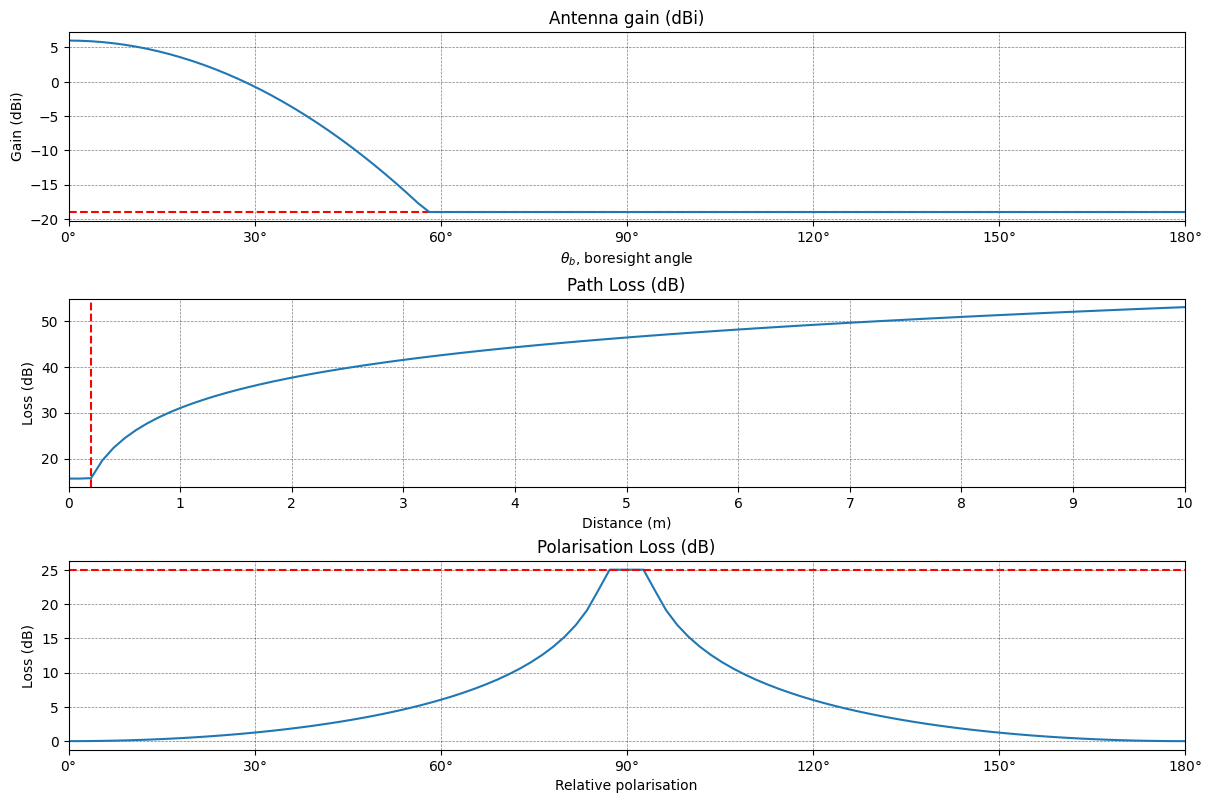

In [92]:
## Antenna gain, path loss, polarisation loss

fig, ax = plt.subplots(3,1, figsize=(12,8), constrained_layout=True)

## Antenna gain
ag_x = np.linspace(0,np.pi, 100)
ag_y = param_default['antenna_gain_peak'] - np.minimum(param_default['antenna_gain_max_loss'], 12*((ag_x/param_default['antenna_gain_half_beamwidth'])**2))
ax[0].axhline(param_default['antenna_gain_peak'] - param_default['antenna_gain_max_loss'], color='red', linestyle='--')
ax[0].plot(ag_x, ag_y)
ax[0].set_title('Antenna gain (dBi)'); ax[0].set_ylabel('Gain (dBi)'); ax[0].set_xlabel(r'$\theta_{b}$, boresight angle')
ticks = np.linspace(0, np.pi, 7)
ax[0].set_xticks(ticks); ax[0].set_xticklabels([f"${np.degrees(t):.0f}\degree$" for t in ticks])
ax[0].grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

## Path loss
pl_x = np.linspace(0,10,100)
pl_y = param_default['path_loss_base_loss'] + 10*param_default['path_loss_los_exponent']*np.log10(np.maximum(param_default['path_loss_min_distance'], pl_x))
ax[1].plot(pl_x, pl_y)
ax[1].set_title('Path Loss (dB)')
ax[1].set_xlabel('Distance (m)'); ax[1].set_ylabel('Loss (dB)')
ax[1].axvline(param_default['path_loss_min_distance'], color='red', linestyle='--')
ax[1].set_xticks(np.linspace(0,10,11)); ax[1].grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

## Polarisation loss
pol_x = np.linspace(0,np.pi,100)
pol_y = np.minimum(param_default['polarization_max_loss'], -20*np.log10(abs(np.cos(pol_x))))
ax[2].plot(pol_x, pol_y)
ticks2 = np.linspace(0, np.pi, 7)
ax[2].set_xticks(ticks2); ax[2].set_xticklabels([f"${np.degrees(t):.0f}\degree$" for t in ticks2])
ax[2].set_title('Polarisation Loss (dB)')
ax[2].set_xlabel(r'Relative polarisation'); ax[2].set_ylabel('Loss (dB)')
ax[2].axhline(param_default['polarization_max_loss'], color='red', linestyle='--')
ax[2].grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

for g in ax: g.margins(x=0)
fig.suptitle('')
plt.show()

/tmp/ipykernel_5239/1157422926.py:10: RuntimeWarning: invalid value encountered in divide
  scanner_tag_vec / scanner_tag_linear_distance, ## normalized


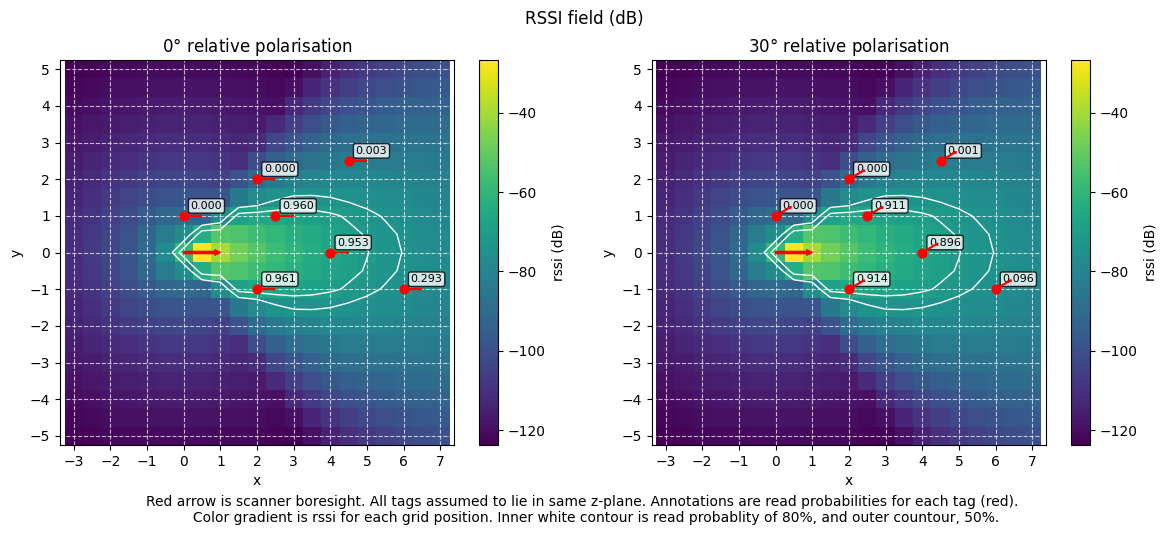

In [96]:
def rssi_plot(fig, ax, points : None | list[RigidTransform] = None, params=param_default):
    rot_id = Rotation.from_euler('xyz', [0,0,0])

    ## Always assume scanner is at (0,0) and boresight is +ve x-axis
    scanner_pose = RigidTransform.from_components([0,0,0], rot_id)

    # Compute rssi (assuming matching polarisation between tag and antenna)
    def f_rssi(x, y):
        return rssi(scanner_pose, RigidTransform.from_components([x, y, 0], rot_id), params=params)[-1] ## -1 is r_power

    # Compute read prob from tx power and rx power (rssi)
    def prob(tp, rp):
        return expit((tp-param_default['tx_threshold_power'])/param_default['tx_read_scaling'])*expit((rp-param_default['rx_threshold_power'])/param_default['rx_read_scaling'])


    # Create grid with resolution 0.5
    x = np.arange(-3, 7.5, 0.5)
    y = np.arange(-5, 5.5, 0.5)
    X, Y = np.meshgrid(x, y)

    
    # Compute Z values for colormap
    Z = np.vectorize(f_rssi)(X,Y)

    # Compute Z probabilities for contour
    Z_prob = np.vectorize(lambda x,y: prob(*rssi(scanner_pose, RigidTransform.from_components([x,y,0], rot_id))))(X,Y)

    # Create 3D surface plot
    ret = ax.pcolormesh(X, Y, Z, shading='auto')
    fig.colorbar(ret, label='rssi (dB)')

    if points is not None:
        ## Iterate over tags
        for t in points:
            ax.scatter(t.translation[0], t.translation[1], color='red', s=40, zorder=3)
            ## Calculate associated read prob given each tag pose
            val = prob(*rssi(scanner_pose, t))
    
            t_ax_x = t.rotation.apply(np.array([0.5,0,0]))
            ax.arrow(
                t.translation[0], t.translation[1], # x, y
                t_ax_x[0], t_ax_x[1], # dx, dy
                color='red',
                width=0.02,
                head_width=0.05,
                head_length=0.05,
                length_includes_head=True,
                zorder=5,
            )
   
            ax.annotate(
                f"{val:.3f}",
                (t.translation[0], t.translation[1]),
                xytext=(5, 5),               # offset in points
                textcoords="offset points",
                fontsize=8,
                bbox=dict(
                    boxstyle="round,pad=0.2",  # or "square,pad=0.2"
                    fc="white",
                    ec="black",
                    alpha=0.8
                ),
            )
    
    ax.set_xticks(np.arange(-3, 8, 1))
    ax.set_yticks(np.arange(-5, 6, 1))
    ax.grid(True, color='white', linestyle='--', linewidth=0.8, alpha=0.7)

    ax.arrow(
        0, 0, # x, y)
        1, 0, # dx, dy
        color='red',
        width=0.06,
        head_width=0.15,
        head_length=0.15,
        length_includes_head=True,
        zorder=5,
    )
    
    ax.contour(
        X, Y, Z_prob,
        levels=[0.8],
        colors='white',
        linewidths=1
    )
    
    ax.contour(
        X, Y, Z_prob,
        levels=[0.5],
        colors='white',
        linewidths=1
    )
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')

fig, ax = plt.subplots(1,2, figsize=(14,5))

pts = [
    RigidTransform.from_components([3,0.5,0], Rotation.from_euler('xyz', [0,0,90], degrees=True))
]

pts = [
    RigidTransform.from_components([2,2,0], rot_id),
    RigidTransform.from_components([2,-1,0], rot_id),
    RigidTransform.from_components([4,0,0], rot_id),
    RigidTransform.from_components([6,-1,0], rot_id),
    RigidTransform.from_components([0,1,0], rot_id),
    RigidTransform.from_components([2.5,1,0], rot_id),
    RigidTransform.from_components([4.5,2.5,0], rot_id),
]

rssi_plot(fig, ax[0], points=pts, params=param_default)

pts_2 = [
    RigidTransform.from_components([2,2,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([2,-1,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([4,0,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([6,-1,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([0,1,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([2.5,1,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
    RigidTransform.from_components([4.5,2.5,0], Rotation.from_euler('xyz', [0,0,30], degrees=True)),
]
rssi_plot(fig, ax[1], points=pts_2, params=param_default)

ax[0].set_title(r'$0\degree$ relative polarisation')
ax[1].set_title(r'$30\degree$ relative polarisation')
fig.suptitle(r'RSSI field (dB)')
fig.text(
    0.5, -0.05,
    "Red arrow is scanner boresight. All tags assumed to lie in same z-plane. Annotations are read probabilities for each tag (red). \n \
    Color gradient is rssi for each grid position. Inner white contour is read probablity of 80%, and outer countour, 50%.",
    ha="center",
    va="bottom",
    fontsize=10,
)
plt.show()

In [101]:
## Creating test files based on above expected RSSIs
model_sdf="""		<model name="{name}">
			<static>true</static>
			<pose> {x} {y} {z} 0 0 0</pose>
			<plugin filename="librfidTag" name="RFIDTag">
				<uid>{name}</uid>
				<data>{data}</data>
			</plugin>
		</model>
"""

sdf_head="""<?xml version="1.0" ?>
<sdf version="1.9">
	<world name="{world_name}">
		<physics name="1ms" type="ignore">
			<max_step_size>0.001</max_step_size>
			<real_time_factor>1.0</real_time_factor>
		</physics>

		<plugin filename="gz-sim-physics-system" name="gz::sim::systems::Physics"></plugin>
		<plugin filename="gz-sim-sensors-system" name="gz::sim::systems::Sensors">
			<render_engine>ogre2</render_engine>
		</plugin>

		<plugin filename="gz-sim-user-commands-system" name="gz::sim::systems::UserCommands"></plugin>

		<model name="scanner">
			<static>true</static>
			<pose>0 0 0 0 0 0</pose>
			<plugin filename="librfidScanner" name="RFIDScanner">
				<antenna_power>30</antenna_power>
				<path_loss_los_exponent>2.2</path_loss_los_exponent>
				<path_loss_base_loss>31</path_loss_base_loss>
				<path_loss_min_distance>0.2</path_loss_min_distance>
				<polarization_max_loss>25</polarization_max_loss>
				<antenna_gain_peak>6</antenna_gain_peak>
				<antenna_gain_max_loss>25</antenna_gain_max_loss>
				<antenna_gain_half_beamwidth>0.7</antenna_gain_half_beamwidth>
				<tag_directional_gain>0</tag_directional_gain>
				<backscatter_loss>20</backscatter_loss>

				<tx_threshold_power>-15</tx_threshold_power>
				<rx_threshold_power>-75</rx_threshold_power>
				<tx_read_scaling>2</tx_read_scaling>
				<rx_read_scaling>2</rx_read_scaling>
				<return_all>true</return_all>
			</plugin>
		</model>
"""

sdf_tail="""	</world>
</sdf>
"""

sdf_full = sdf_head.format(world_name="rssi_test_standard")

## Create an std::map, and a corresponding sdf for our poses
idx=0
for i in range(1,6):
     for j in range(1,6):
         for k in range(1,6):
             rpower = rssi(scanner_pose, RigidTransform.from_components([i, j, k], rot_id))
             print(f'{{"tag{idx}", {rpower[-1]}}},')

             sdf_full += model_sdf.format(name=f"tag{idx}", x=i, y=j, z=k, data=f"tag {idx} data")
             idx += 1

sdf_full += sdf_tail
with open('worlds/rssi_test_default.sdf', "w") as wfile:
    wfile.write(sdf_full)

{"tag0", -95.19690470741703},
{"tag1", -107.11932750844016},
{"tag2", -112.91063907348095},
{"tag3", -117.61599511227273},
{"tag4", -121.49000281149772},
{"tag5", -107.11932750844016},
{"tag6", -110.99333520766515},
{"tag7", -115.21481678492124},
{"tag8", -119.08882448414623},
{"tag9", -122.49666760383258},
{"tag10", -112.91063907348095},
{"tag11", -115.21481678492124},
{"tag12", -118.13257922096224},
{"tag13", -121.129413655358},
{"tag14", -123.96949697570606},
{"tag15", -117.61599511227273},
{"tag16", -119.08882448414623},
{"tag17", -121.129413655358},
{"tag18", -123.40730667731353},
{"tag19", -125.7114843887538},
{"tag20", -121.49000281149772},
{"tag21", -122.49666760383258},
{"tag22", -123.96949697570606},
{"tag23", -125.7114843887538},
{"tag24", -127.5665438741546},
{"tag25", -75.67354490199044},
{"tag26", -95.6413274661585},
{"tag27", -114.86809077051639},
{"tag28", -119.08882448414623},
{"tag29", -122.49666760383258},
{"tag30", -95.6413274661585},
{"tag31", -108.4422245166322},
